In [1]:
pip install numpy torch pandas matplotlib seaborn dataclasses typing

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 12.3/12.3 MB 99.7 MB/s  0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ------- ------------------------------- 22.8/123.0 MB 116.5 MB/s eta 0:00:01
   --------------- ----------------------- 47.4/123.0 MB 116.5 MB/s eta 0:00:01
   ---------------------- ---------------- 71.0/123.0 MB 116.5 MB/s eta 0:00:01
   ------------------------------ -------- 95.9/123.0 MB 116.5 MB/s eta 0:00:01
   -------------------------------------  120.6/123.0 MB 116.5 MB/s eta 0:00:01
   ---------------------------------------- 123.0/123

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Example 1

In [2]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dataclasses import dataclass
from typing import Literal
from IPython.display import display

# Apply Seaborn style configuration for clean academic plots
sns.set_theme(style="whitegrid")
# Fetch the default Seaborn color palette colors
SEABORN_PALETTE = sns.color_palette("deep")

torch.manual_seed(41)
np.random.seed(41)
DEVICE = torch.device("cpu")

In [4]:
# ── Agent configs ─────────────────────────────────────────────────
@dataclass
class AgentConfig:
    name: str
    objective: str
    phi: float
    alpha0: float
    q0: float

Q0 = 1002.0

AGENTS = [
    AgentConfig('Agent 1', 'market_making', phi=3.0, alpha0=-2.0, q0=Q0 - 2),
    AgentConfig('Agent 2', 'market_making', phi=5.0, alpha0=-0.8, q0=Q0 - 2),
    AgentConfig('Agent 3', 'market_making', phi=7.0, alpha0=-2.0, q0=Q0 - 2),
]

# ── Market params ─────────────────────────────────────────────────
@dataclass
class MarketParams:
    S0: float = 100.0
    V0: float = 0.04
    kappa_v: float = 4.0
    theta_v: float = 0.04
    sigma_v: float = 0.64
    rho: float = -0.5
    kappa_a: float = 1.0 
    sigma_a: float = 0.1
    lam0: float = 40.0 
    kappa_l: float = 8.0
    eta: float = 4.0 
    A: float = 2400.0
    kappa_f: float = 4.0
    T: float = 1.0
    dt: float = 0.005
    base_spread: float = 6.0

    @property
    def M(self):
        return int(self.T / self.dt)

MP = MarketParams()

# ── Policy network ────────────────────────────────────────────────
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_net = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.head = nn.Linear(64, 2)
        self.softplus = nn.Softplus()
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, std=0.01)
                nn.init.constant_(module.bias, 0.01)
        nn.init.normal_(self.head.weight, std=0.005)
        nn.init.constant_(self.head.bias, -2.1) 

    def forward(self, z):
        hidden = self.feature_net(z)
        return self.softplus(self.head(hidden))

In [5]:
# ── SGLD ──────────────────────────────────────────────────────────
class SGLD(torch.optim.Optimizer):
    def __init__(self, params, lr=3e-3, beta_inv=5e-5):
        super().__init__(params, dict(lr=lr, beta_inv=beta_inv))

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure else None
        for group in self.param_groups:
            noise_scale = (2 * group['lr'] * group['beta_inv']) ** 0.5
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data -= group['lr'] * p.grad.data
                p.data += noise_scale * torch.randn_like(p.data)
        return loss

# ── Simulator ─────────────────────────────────────────────────────
def simulate_batch(policy, cfg: AgentConfig, B: int, mp: MarketParams = MP, stochastic_fills: bool = False):
    dt, M = mp.dt, mp.M

    S = torch.full((B,), mp.S0)
    V = torch.full((B,), mp.V0)
    q = torch.full((B,), cfg.q0)
    alp = torch.full((B,), cfg.alpha0)
    lp = torch.full((B,), mp.lam0)
    lm = torch.full((B,), mp.lam0)

    cash = torch.zeros(B)
    inv_pen = torch.zeros(B)
    spread_pen = torch.zeros(B)

    spreads_hist = []
    inv_hist = []

    # Benchmark initial frictionless capture value
    initial_value_benchmark = cfg.q0 * mp.S0

    for m in range(M):
        t = m * dt
        q_target = cfg.q0 * (1.0 - t / mp.T)

        z = torch.stack([
            torch.full((B,), t),
            torch.log(S / mp.S0),
            (q - q_target) / Q0,  
            V / mp.theta_v,
            alp / (mp.sigma_a + 1e-8),
            lp / mp.lam0,
            lm / mp.lam0,
        ], dim=1)

        delta = policy(z)
        dp, dm = delta[:, 0], delta[:, 1]
        spreads_hist.append(delta.detach())
        inv_hist.append(q.detach().clone())

        rate_buy = mp.A * torch.exp(-mp.kappa_f * dp)
        rate_sell = mp.A * torch.exp(-mp.kappa_f * dm)

        if stochastic_fills:
            buy_flow = torch.poisson(rate_buy * dt).float()
            sell_flow = torch.poisson(rate_sell * dt).float()
        else:
            buy_flow = rate_buy * dt
            sell_flow = rate_sell * dt

        actual_sell = torch.minimum(q, sell_flow)
        actual_buy = torch.minimum(Q0 - q, buy_flow)

        cash += actual_sell * (S + dm) - actual_buy * (S - dp)
        q = (q - actual_sell + actual_buy)

        inv_pen += cfg.phi * (q - q_target) ** 2 * V * dt
        spread_pen += 0.02 * (dp + dm).mean() * dt

        dW_S = torch.randn(B) * dt ** 0.5
        dW_V = mp.rho * dW_S + (1 - mp.rho ** 2) ** 0.5 * torch.randn(B) * dt ** 0.5
        S = S + alp * S * dt + V.sqrt() * S * dW_S
        V = (V + mp.kappa_v * (mp.theta_v - V) * dt + mp.sigma_v * V.sqrt() * dW_V).clamp(1e-5)
        alp = alp - mp.kappa_a * alp * dt + mp.sigma_a * torch.randn(B) * dt ** 0.5

        dN = (actual_sell + actual_buy).clamp(0, 5)
        lp = (lp - mp.kappa_l * (lp - mp.lam0) * dt + mp.eta * dN).clamp(mp.lam0 * 0.1)
        lm = (lm - mp.kappa_l * (lm - mp.lam0) * dt + mp.eta * dN).clamp(mp.lam0 * 0.1)

    terminal_value = q * (S - mp.base_spread)
    pnl = cash + terminal_value
    
    # Slippage per individual simulation run path
    slippage_paths = initial_value_benchmark - pnl
    
    loss = -(pnl - inv_pen).mean() + spread_pen.mean()

    return loss, torch.stack(spreads_hist, dim=1), torch.stack(inv_hist, dim=1), slippage_paths.detach()


<>:72: SyntaxWarning: invalid escape sequence '\d'
<>:72: SyntaxWarning: invalid escape sequence '\d'
C:\Users\yn422\AppData\Local\Temp\ipykernel_20336\1979945970.py:72: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Spread Distance ($\delta$)', fontsize=11)



  [Agent 1]  φ=3.0  α0=-2.0  q0=1000.0
    ep  50/200  L=-43986.28  ||g||=73891.12
    ep 100/200  L=-56980.56  ||g||=3975.60
    ep 150/200  L=-59271.59  ||g||=6328.96
    ep 200/200  L=-58610.20  ||g||=17336.08

  [Agent 2]  φ=5.0  α0=-0.8  q0=1000.0
    ep  50/200  L=-66621.28  ||g||=66395.73
    ep 100/200  L=-77047.10  ||g||=2027.95
    ep 150/200  L=-77413.19  ||g||=6493.02
    ep 200/200  L=-76521.24  ||g||=1143.77

  [Agent 3]  φ=7.0  α0=-2.0  q0=1000.0
    ep  50/200  L=-38548.46  ||g||=100515.99
    ep 100/200  L=-54508.09  ||g||=9543.43
    ep 150/200  L=-55428.52  ||g||=21420.78
    ep 200/200  L=-55321.50  ||g||=17142.79


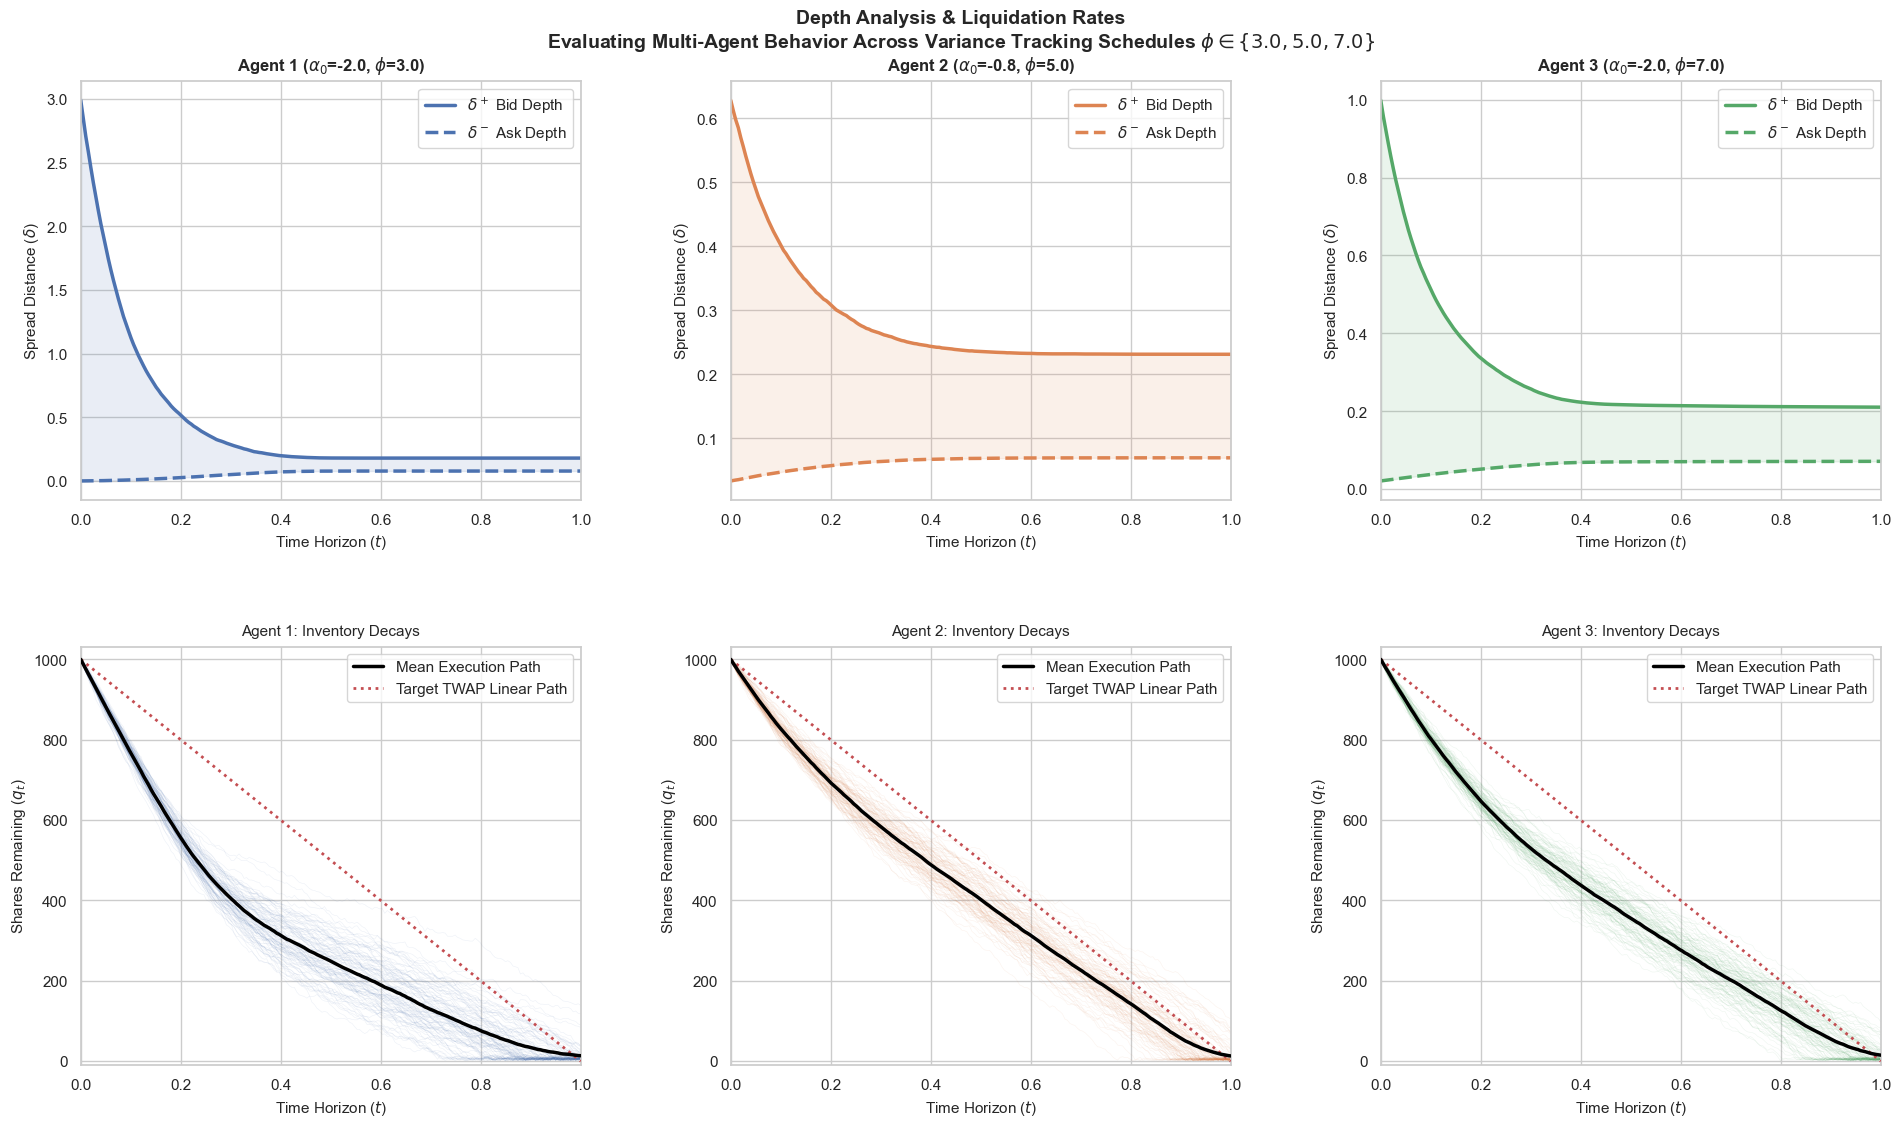


Simulation and evaluation finished cleanly.

── Sample Run Slippage Details (First 5 Paths Highlight) ──

Agent 1 - First 5 runs individual slippages: [36496.113 48560.883 35240.31  42527.23  35752.992]

Agent 2 - First 5 runs individual slippages: [21302.86   14113.3125 16548.227  21990.805  35311.633 ]

Agent 3 - First 5 runs individual slippages: [52863.746 28967.672 39253.758 46657.25  39045.49 ]

── Comprehensive Performance Statistics ─────────────────────
        Mean Unsold Shares Mean Slippage ($) Std Dev Slippage Min Slippage ($) Max Slippage ($)
Agent                                                                                          
Agent 1               13.7          34741.64          5227.86         25312.52         49828.02
Agent 2               13.1          20383.28          6893.94          -480.52         47886.77
Agent 3               15.1          40254.31          5036.43         28967.67         52863.75


In [6]:
# ── Training ──────────────────────────────────────────────────────
def train_agent(cfg, n_epochs=200, B=128, lr=3e-3, beta_inv=5e-5):
    policy = PolicyNetwork().to(DEVICE)
    opt = SGLD(policy.parameters(), lr=lr, beta_inv=beta_inv)
    losses = []
    grad_norms = []

    probe_state = torch.tensor([
        0.0, 0.0, 0.0, 1.0,
        cfg.alpha0 / (MP.sigma_a + 1e-8),
        1.0, 1.0
    ], dtype=torch.float32).unsqueeze(0)

    print(f"\n  [{cfg.name}]  φ={cfg.phi}  α0={cfg.alpha0}  q0={cfg.q0}")
    for ep in range(n_epochs):
        opt.zero_grad()
        loss, _, _, _ = simulate_batch(policy, cfg, B, stochastic_fills=False)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), 5.0)
        opt.step()

        losses.append(loss.item())
        grad_norms.append(float(grad_norm))

        if (ep + 1) % 50 == 0:
            print(f"    ep {ep+1:3d}/{n_epochs}  L={loss.item():.2f}  ||g||={float(grad_norm):.2f}")

    return policy, losses, grad_norms

@torch.no_grad()
def evaluate_agent(policy, cfg, n_paths=100):
    _, spreads, inv, slippage_paths = simulate_batch(policy, cfg, n_paths, stochastic_fills=True)
    return {
        'mean_bid': spreads[:, :, 0].mean(0).numpy(),
        'mean_ask': spreads[:, :, 1].mean(0).numpy(),
        'inv_paths': inv.numpy(),
        'mean_inv': inv.mean(0).numpy(),
        'slippage_paths': slippage_paths.numpy(),  # Expose the 100 sample runs array
        'cfg': cfg,
    }

# ── Main ──────────────────────────────────────────────────────────
def main():
    results = {}
    for cfg in AGENTS:
        policy, losses, grad_norms = train_agent(cfg)
        res = evaluate_agent(policy, cfg)
        results[cfg.name] = res

    tg = np.linspace(0, MP.T, MP.M)
    
    COLOURS = {
        'Agent 1': SEABORN_PALETTE[0],
        'Agent 2': SEABORN_PALETTE[1],
        'Agent 3': SEABORN_PALETTE[2],
    }

    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.30, top=0.90, bottom=0.08, left=0.06, right=0.96)

    # ROW 0: Mean Spread Depths
    for col, (name, res) in enumerate(results.items()):
        ax = fig.add_subplot(gs[0, col])
        c = COLOURS[name]
        
        ax.plot(tg, res['mean_bid'], color=c, lw=2.5, label=r'$\delta^+$ Bid Depth')
        ax.plot(tg, res['mean_ask'], color=c, lw=2.5, ls='--', label=r'$\delta^-$ Ask Depth')
        ax.fill_between(tg, res['mean_bid'], res['mean_ask'], color=c, alpha=0.12)
        
        ax.set_title(fr"{name} ($\alpha_0$={res['cfg'].alpha0}, $\phi$={res['cfg'].phi})", fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Time Horizon ($t$)', fontsize=11)
        ax.set_ylabel('Spread Distance ($\delta$)', fontsize=11)
        ax.legend(loc='upper right', frameon=True, fontsize=11)
        ax.set_xlim(0, MP.T)

    # ROW 1: Inventory Decay Realizations
    for col, (name, res) in enumerate(results.items()):
        ax = fig.add_subplot(gs[1, col])
        c = COLOURS[name]
        inv = res['inv_paths']
        
        for i in range(inv.shape[0]):
            ax.plot(tg, inv[i], color=c, lw=0.40, alpha=0.10)
            
        ax.plot(tg, res['mean_inv'], color='black', lw=2.5, label='Mean Execution Path', zorder=5)
        ax.plot(tg, res['cfg'].q0 * (1.0 - tg / MP.T), color=SEABORN_PALETTE[3], lw=2.0, ls=':', label='Target TWAP Linear Path', zorder=4)
        
        ax.set_title(f"{name}: Inventory Decays", fontsize=11, pad=8)
        ax.set_xlabel('Time Horizon ($t$)', fontsize=11)
        ax.set_ylabel('Shares Remaining ($q_t$)', fontsize=11)
        ax.set_ylim(-10, Q0 + 30)
        ax.set_xlim(0, MP.T)
        ax.legend(loc='upper right', frameon=True, fontsize=11)

    fig.suptitle(
        'Depth Analysis & Liquidation Rates\n'
        r'Evaluating Multi-Agent Behavior Across Variance Tracking Schedules $\phi \in \{3.0, 5.0, 7.0\}$',
        fontsize=14, fontweight='bold', y=0.96
    )

    display(fig)
    plt.close(fig)
    print("\nSimulation and evaluation finished cleanly.")

    # ── Print Full Path-by-Path Slippage for Verification ───────────
    print('\n── Sample Run Slippage Details (First 5 Paths Highlight) ──')
    for name, res in results.items():
        print(f"\n{name} - First 5 runs individual slippages: {res['slippage_paths'][:5]}")

    # Terminal Consolidated Summary Table
    rows = []
    for name, res in results.items():
        ti = res['inv_paths'][:, -1]
        slip = res['slippage_paths']
        rows.append({
            'Agent': name,
            'Mean Unsold Shares': f"{ti.mean():.1f}",
            'Mean Slippage ($)': f"{slip.mean():.2f}",
            'Std Dev Slippage': f"{slip.std():.2f}",
            'Min Slippage ($)': f"{slip.min():.2f}",
            'Max Slippage ($)': f"{slip.max():.2f}",
        })
    df = pd.DataFrame(rows).set_index('Agent')
    print('\n── Comprehensive Performance Statistics ─────────────────────')
    print(df.to_string())
    return df

if __name__ == '__main__':
    main()

### Example 2

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dataclasses import dataclass
from typing import Literal
from IPython.display import display

# Apply Seaborn style configuration for clean academic plots
sns.set_theme(style="whitegrid")
# Fetch the default Seaborn color palette colors
SEABORN_PALETTE = sns.color_palette("deep")

torch.manual_seed(41)
np.random.seed(41)
DEVICE = torch.device("cpu")

In [ ]:
# ── Agent configs ─────────────────────────────────────────────────
@dataclass
class AgentConfig:
    name: str
    objective: str
    phi: float
    alpha0: float
    q0: float

Q0 = 1002.0

AGENTS = [
    AgentConfig('Agent 1', 'market_making', phi=3.0, alpha0= 0.0, q0=Q0 - 2),
    AgentConfig('Agent 2', 'market_making', phi=5.0, alpha0=-0.8, q0=Q0 - 2),
    AgentConfig('Agent 3', 'market_making', phi=7.0, alpha0=-2.0, q0=Q0 - 2),
]

# ── Market params ─────────────────────────────────────────────────
@dataclass
class MarketParams:
    S0: float = 100.0
    V0: float = 0.04
    kappa_v: float = 4.0
    theta_v: float = 0.04
    sigma_v: float = 0.64
    rho: float = -0.5
    kappa_a: float = 1.0 
    sigma_a: float = 0.1
    lam0: float = 40.0 
    kappa_l: float = 8.0
    eta: float = 4.0 
    A: float = 2400.0
    kappa_f: float = 4.0
    T: float = 1.0
    dt: float = 0.005
    base_spread: float = 6.0

    @property
    def M(self):
        return int(self.T / self.dt)

MP = MarketParams()

# ── Policy network ────────────────────────────────────────────────
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_net = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.head = nn.Linear(64, 2)
        self.softplus = nn.Softplus()
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, std=0.01)
                nn.init.constant_(module.bias, 0.01)
        nn.init.normal_(self.head.weight, std=0.005)
        nn.init.constant_(self.head.bias, -2.1) 

    def forward(self, z):
        hidden = self.feature_net(z)
        return self.softplus(self.head(hidden))

# ── SGLD ──────────────────────────────────────────────────────────
class SGLD(torch.optim.Optimizer):
    def __init__(self, params, lr=3e-3, beta_inv=5e-5):
        super().__init__(params, dict(lr=lr, beta_inv=beta_inv))

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure else None
        for group in self.param_groups:
            noise_scale = (2 * group['lr'] * group['beta_inv']) ** 0.5
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data -= group['lr'] * p.grad.data
                p.data += noise_scale * torch.randn_like(p.data)
        return loss

# ── Simulator ─────────────────────────────────────────────────────
def simulate_batch(policy, cfg: AgentConfig, B: int, mp: MarketParams = MP, stochastic_fills: bool = False):
    dt, M = mp.dt, mp.M

    S = torch.full((B,), mp.S0)
    V = torch.full((B,), mp.V0)
    q = torch.full((B,), cfg.q0)
    alp = torch.full((B,), cfg.alpha0)
    lp = torch.full((B,), mp.lam0)
    lm = torch.full((B,), mp.lam0)

    cash = torch.zeros(B)
    inv_pen = torch.zeros(B)
    spread_pen = torch.zeros(B)

    spreads_hist = []
    inv_hist = []

    for m in range(M):
        t = m * dt
        q_target = cfg.q0 * (1.0 - t / mp.T)

        z = torch.stack([
            torch.full((B,), t),
            torch.log(S / mp.S0),
            (q - q_target) / Q0,  
            V / mp.theta_v,
            alp / (mp.sigma_a + 1e-8),
            lp / mp.lam0,
            lm / mp.lam0,
        ], dim=1)

        delta = policy(z)
        dp, dm = delta[:, 0], delta[:, 1]
        spreads_hist.append(delta.detach())
        inv_hist.append(q.detach().clone())

        rate_buy = mp.A * torch.exp(-mp.kappa_f * dp)
        rate_sell = mp.A * torch.exp(-mp.kappa_f * dm)

        if stochastic_fills:
            buy_flow = torch.poisson(rate_buy * dt).float()
            sell_flow = torch.poisson(rate_sell * dt).float()
        else:
            buy_flow = rate_buy * dt
            sell_flow = rate_sell * dt

        actual_sell = torch.minimum(q, sell_flow)
        actual_buy = torch.minimum(Q0 - q, buy_flow)

        cash += actual_sell * (S + dm) - actual_buy * (S - dp)
        q = (q - actual_sell + actual_buy)

        inv_pen += cfg.phi * (q - q_target) ** 2 * V * dt
        spread_pen += 0.02 * (dp + dm).mean() * dt

        dW_S = torch.randn(B) * dt ** 0.5
        dW_V = mp.rho * dW_S + (1 - mp.rho ** 2) ** 0.5 * torch.randn(B) * dt ** 0.5
        S = S + alp * S * dt + V.sqrt() * S * dW_S
        V = (V + mp.kappa_v * (mp.theta_v - V) * dt + mp.sigma_v * V.sqrt() * dW_V).clamp(1e-5)
        alp = alp - mp.kappa_a * alp * dt + mp.sigma_a * torch.randn(B) * dt ** 0.5

        dN = (actual_sell + actual_buy).clamp(0, 5)
        lp = (lp - mp.kappa_l * (lp - mp.lam0) * dt + mp.eta * dN).clamp(mp.lam0 * 0.1)
        lm = (lm - mp.kappa_l * (lm - mp.lam0) * dt + mp.eta * dN).clamp(mp.lam0 * 0.1)

    terminal_value = q * (S - mp.base_spread)
    pnl = cash + terminal_value
    loss = -(pnl - inv_pen).mean() + spread_pen.mean()

    return loss, torch.stack(spreads_hist, dim=1), torch.stack(inv_hist, dim=1)

# ── Training ──────────────────────────────────────────────────────
def train_agent(cfg, n_epochs=200, B=128, lr=3e-3, beta_inv=5e-5):
    policy = PolicyNetwork().to(DEVICE)
    opt = SGLD(policy.parameters(), lr=lr, beta_inv=beta_inv)
    losses = []
    grad_norms = []

    probe_state = torch.tensor([
        0.0, 0.0, 0.0, 1.0,
        cfg.alpha0 / (MP.sigma_a + 1e-8),
        1.0, 1.0
    ], dtype=torch.float32).unsqueeze(0)

    print(f"\n  [{cfg.name}]  φ={cfg.phi}  α0={cfg.alpha0}  q0={cfg.q0}")
    for ep in range(n_epochs):
        opt.zero_grad()
        loss, _, _ = simulate_batch(policy, cfg, B, stochastic_fills=False)
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), 5.0)
        opt.step()

        losses.append(loss.item())
        grad_norms.append(float(grad_norm))

        if (ep + 1) % 50 == 0:
            with torch.no_grad():
                probe_delta = policy(probe_state)[0].cpu().numpy()
            print(f"    ep {ep+1:3d}/{n_epochs}  L={loss.item():.2f}  ||g||={float(grad_norm):.2f}")

    return policy, losses, grad_norms

@torch.no_grad()
def evaluate_agent(policy, cfg, n_paths=100):
    _, spreads, inv = simulate_batch(policy, cfg, n_paths, stochastic_fills=True)
    return {
        'mean_bid': spreads[:, :, 0].mean(0).numpy(),
        'mean_ask': spreads[:, :, 1].mean(0).numpy(),
        'inv_paths': inv.numpy(),
        'mean_inv': inv.mean(0).numpy(),
        'cfg': cfg,
    }

# ── Main ──────────────────────────────────────────────────────────
def main():
    results = {}
    for cfg in AGENTS:
        policy, losses, grad_norms = train_agent(cfg)
        res = evaluate_agent(policy, cfg)
        results[cfg.name] = res

    tg = np.linspace(0, MP.T, MP.M)
    
    # Map the agents to the Seaborn palette colors dynamically
    COLOURS = {
        'Agent 1': SEABORN_PALETTE[0],
        'Agent 2': SEABORN_PALETTE[1],
        'Agent 3': SEABORN_PALETTE[2],
    }

    # Redefined layout to precisely fit 2 rows of 3 plots
    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.30, top=0.90, bottom=0.08, left=0.06, right=0.96)

    # ROW 0: Mean Spread Depths (Bid and Ask Depth)
    for col, (name, res) in enumerate(results.items()):
        ax = fig.add_subplot(gs[0, col])
        c = COLOURS[name]
        
        ax.plot(tg, res['mean_bid'], color=c, lw=2.5, label=r'$\delta^+$ Bid Depth')
        ax.plot(tg, res['mean_ask'], color=c, lw=2.5, ls='--', label=r'$\delta^-$ Ask Depth')
        ax.fill_between(tg, res['mean_bid'], res['mean_ask'], color=c, alpha=0.12)
        
        ax.set_title(fr"{name} ($\alpha_0$={res['cfg'].alpha0}, $\phi$={res['cfg'].phi})", fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Time Horizon ($t$)', fontsize=11)
        ax.set_ylabel('Spread Distance ($\delta$)', fontsize=11)
        ax.legend(loc='upper right', frameon=True, fontsize=11)
        ax.set_xlim(0, MP.T)

    # ROW 1: Rate of Liquidation (Stock Inventory Paths)
    for col, (name, res) in enumerate(results.items()):
        ax = fig.add_subplot(gs[1, col])
        c = COLOURS[name]
        inv = res['inv_paths']
        
        # Plot individual simulated realization paths
        for i in range(inv.shape[0]):
            ax.plot(tg, inv[i], color=c, lw=0.40, alpha=0.10)
            
        # Highlight empirical mean trajectory and target schedule
        ax.plot(tg, res['mean_inv'], color='black', lw=2.5, label='Mean Execution Path', zorder=5)
        ax.plot(tg, res['cfg'].q0 * (1.0 - tg / MP.T), color=SEABORN_PALETTE[3], lw=2.0, ls=':', label='Target TWAP Linear Path', zorder=4)
        
        ax.set_title(f"{name}: Inventory Decays", fontsize=11, pad=8)
        ax.set_xlabel('Time Horizon ($t$)', fontsize=11)
        ax.set_ylabel('Shares Remaining ($q_t$)', fontsize=11)
        ax.set_ylim(-10, Q0 + 30)
        ax.set_xlim(0, MP.T)
        ax.legend(loc='upper right', frameon=True, fontsize=11)

    fig.suptitle(
        'Depth Analysis & Liquidation Rates\n'
        r'Evaluating Multi-Agent Behavior Across Variance Tracking Schedules $\phi \in \{3.0, 5.0, 7.0\}$',
        fontsize=14, fontweight='bold', y=0.96
    )

    display(fig)
    plt.close(fig)
    print("\nSimulation and evaluation finished cleanly.")

    rows = []
    for name, res in results.items():
        ti = res['inv_paths'][:, -1]
        rows.append({
            'Agent': name,
            'Initial Bid': f"{res['mean_bid'][0]:.3f}",
            'Initial Ask': f"{res['mean_ask'][0]:.3f}",
            'Final Bid': f"{res['mean_bid'][-1]:.3f}",
            'Final Ask': f"{res['mean_ask'][-1]:.3f}",
            'Mean Unsold Shares': f"{ti.mean():.1f}",
            'Median Unsold Shares': f"{np.median(ti):.1f}",
        })
    df = pd.DataFrame(rows).set_index('Agent')
    print('\n── Terminal Statistics ──────────────────────────────')
    print(df.to_string())
    return df

if __name__ == '__main__':
    main()
